In [1]:
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
amb_090160=gis.content.search("090160")[0].layers[0]
amb_090160.url

'https://pythonapi.playground.esri.com/server/rest/services/090160/ImageServer'

In [5]:
# forecast=gis.content.search("forecast")[0].layers[0]
# forecast.url

In [6]:
aoi = {"xmin": 4488984.30552307,"ymin": 5478865.93230073,"xmax": 4489394.36741995,"ymax": 5479138.57516793,"spatialReference": {"wkt": "PROJCS[\"Deutsches_Hauptdreiecksnetz_Transverse_Mercator\",GEOGCS[\"GCS_Deutsches_Hauptdreiecksnetz\",DATUM[\"D_Deutsches_Hauptdreiecksnetz\",SPHEROID[\"Bessel_1841\",6377397.155,299.1528128]],PRIMEM[\"Greenwich\",0.0],UNIT[\"Degree\",0.0174532925199433]],PROJECTION[\"Transverse_Mercator\"],PARAMETER[\"false_easting\",4500000.0],PARAMETER[\"false_northing\",0.0],PARAMETER[\"central_meridian\",12.0],PARAMETER[\"scale_factor\",1.0],PARAMETER[\"latitude_of_origin\",0.0],UNIT[\"Meter\",1.0]]"}}

Rendering Rule : 
{'rasterFunction': 'Hillshade',
 'rasterFunctionArguments': {
  'Azimuth': 215.0,
  'Altitude': 75.0,
  'ZFactor': 0.3,
  'SlopeType': 1,
  'HillshadeType': 1}}

Generate Raster with raster_function and output_name as inputs

Submitted.
Executing...
GenerateRaster GP Job: j9415187c390c4b989b17d5088693946a finished successfully.


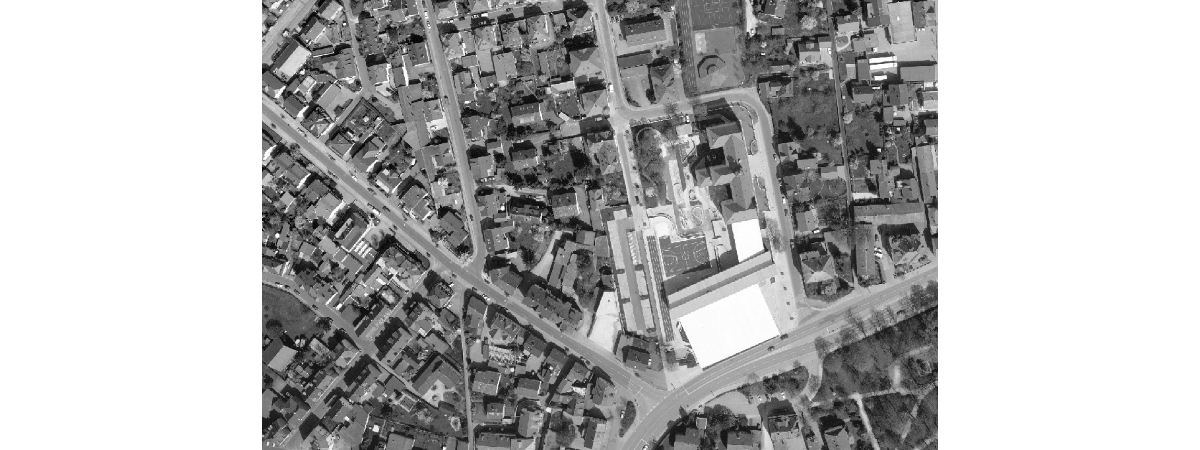

In [7]:
rf={'rasterFunction': 'Grayscale', 'rasterFunctionArguments': {"Raster":amb_090160.url, "conversionParameters":[0.1,0.3,0.6]}} 
gen_raster_op_1 = arcgis.raster.analytics.generate_raster(raster_function=rf,
                                                          function_arguments=None, 
                                                          output_raster_properties=None, 
                                                          output_name="generate_raster" + str(datetime.now().strftime("%Y%m%d%H%M%S")),
                                                          context={"extent":aoi},
                                                          gis=gis)
gen_raster_op_1.layers[0]

Submitted.
Executing...
GenerateRaster GP Job: jb22cb4f5bfd745ff9e8ec9d6097b810f finished successfully.


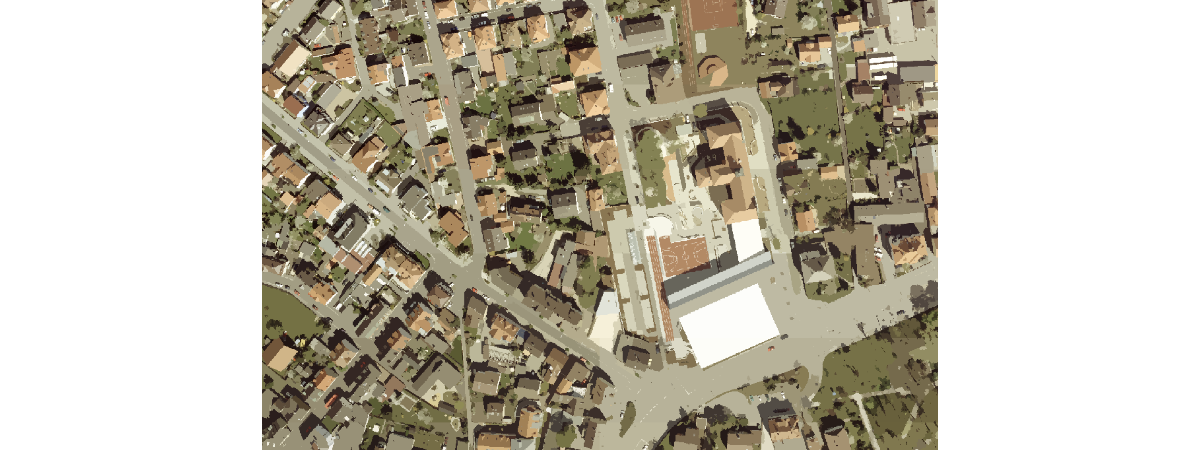

In [8]:
arcgis.env.analysis_extent = aoi
gen_raster_op_2 = arcgis.raster.analytics.generate_raster(raster_function={"rasterFunction": "SegmentMeanShift"}, 
                                                          function_arguments={"Raster":amb_090160.url}, 
                                                          output_raster_properties={"Segmented":1}, 
                                                          output_name="generate_raster" + str(datetime.now().strftime("%Y%m%d%H%M%S")), 
                                                          gis=gis,
                                                          future=True)
gen_raster_op_2.result().layers[0]

In [9]:
arcgis.env.analysis_extent = None

Using save function

Submitted.
Executing...
GenerateRaster GP Job: jfa00ac0c62f44666a7fe3c23a0e1dd56 finished successfully.


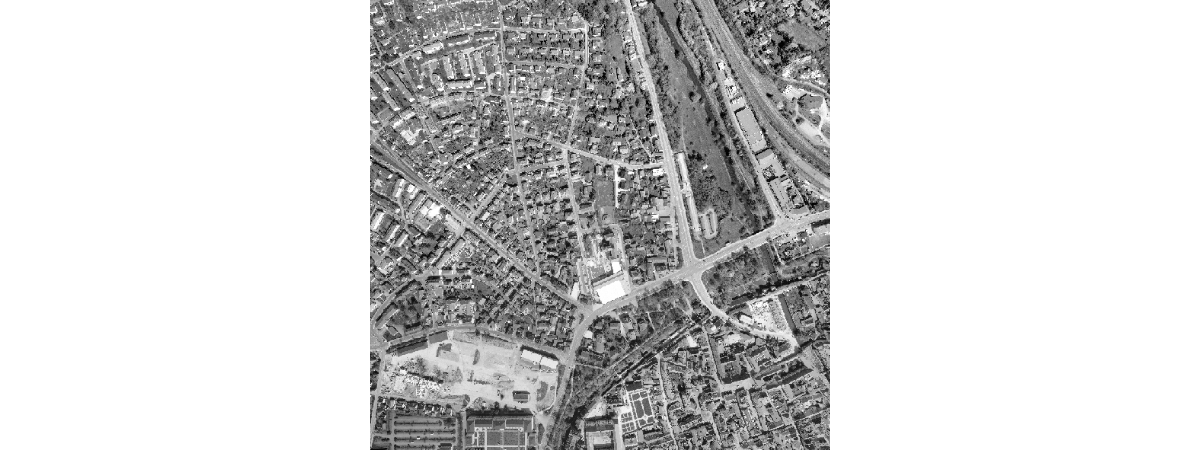

In [10]:
grayscale_op = arcgis.raster.functions.grayscale(raster=amb_090160)
save_op_1 = grayscale_op.save(output_name="save" + str(datetime.now().strftime("%Y%m%d%H%M%S")),future=True)
save_op_1.result().layers[0]

Process as Multidmensional and build transpose #Supported in 10.8

In [11]:
# generate_raster_3 = arcgis.raster.analytics.generate_raster(raster_function={'rasterFunction': 'Clip',"rasterFunctionArguments":{'ClippingGeometry': {'xmin': 6728735.12415648,'ymin': 3466963.30055506,'xmax': 8153108.81132537,'ymax': 4414004.04973266,'spatialReference': {'wkid': 102100, 'latestWkid': 3857}},'ClipType': 1,'Raster': {"url":forecast.url}}},
#                                                             function_arguments=None,
#                                                             output_name="generate_raster" + str(datetime.now().strftime("%Y%m%d%H%M%S")),
#                                                             process_as_multidimensional=True, 
#                                                             build_transpose=False,
#                                                             future=True,
#                                                             gis=gis)
# generate_raster_3.result().layers[0]

<h4> Clean Up

In [12]:
gen_raster_op_1.delete()

True

In [13]:
gen_raster_op_2.result().delete()

True

In [14]:
save_op_1.result().delete()

True

In [17]:
#generate_raster_3.result().delete()